<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/ESAA_YB_WEEK12_study_0522.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ch7. 1~2 (p.431 ~ 449)

#7. 군집화

##7.1 K-평균 알고리즘 이해
- 군집화에서 가장 일반적으로 사용되는 알고리즘
- 군집 중심(cetroid)이라는 특정한 임의의 지점을 선택해 해당 중심에 가장 가까운 포인트들을 선택하는 군집화 기법
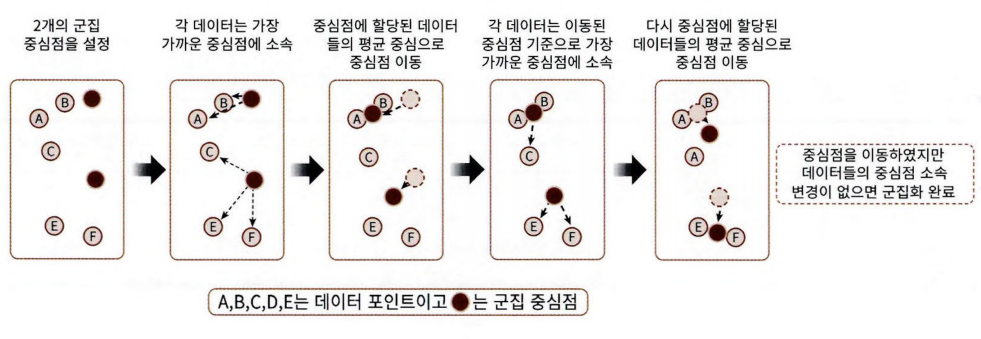

- K-평균의 장점
  - 일반적인 군집화에서 가장 많이 활용되는 알고리즘
  - 알고리즘이 쉽고 간결함.
- K-평균의 단점
  - 거리 기반 알고리즘으로 속성의 개수가 매우 많을 경우 군집화 정확도가 떨어짐.
  - 반복을 수행하는데, 반복 횟수가 많을 경우 수행 시간이 매우 느려짐.
  - 몇 개의 군집(cluster)을 선택해야 할지 가이드하기가 어려움.

###사이킷런 KMeans 클래스 소개

```
class sklearn.cluster.KMeans(n_clusters=8, init='k-means++', n_init=10, max_iter=300, tol=0.0001,
                             precompute_distances='auto', verbose=0, random_state=None,
                             copy_x=True, n_jobs=1, algorithm='auto')
```

####파라미터
- n_clusters
  - KMeans 초기화 파라미터 중 가장 중요한 파라미터
  - 군집화할 개수(군집 중심점의 개수)
- init
  - 초기에 군집 중심점의 좌표를 설정할 방식
  - 보통 임의로 중심을 설정하지 않고 일반적으로 k-means++방식으로 최초 설정
- max_iter
  - 최대 반복 횟수
  - 이 횟수 이전에 모든 데이터의 중심점 이동이 없으면 종료함.

###K-평균을 이용한 붓꽃 데이터 세트 군집화

In [6]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
# 더 편리한 데이터 핸들링을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [7]:
# 3개의 그룹으로 군집화
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
kmeans.fit(irisDF)

KMeans(n_clusters=3, random_state=0)

In [8]:
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [9]:
irisDF['target'] = iris.target
irisDF['cluster'] = kmeans.labels_
iris_result = irisDF.groupby(['target', 'cluster'])['sepal_length'].count()
print(iris_result)

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)

irisDF['pca_x'] = pca_transformed[:,0]
irisDF['pca_y'] = pca_transformed[:,1]
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


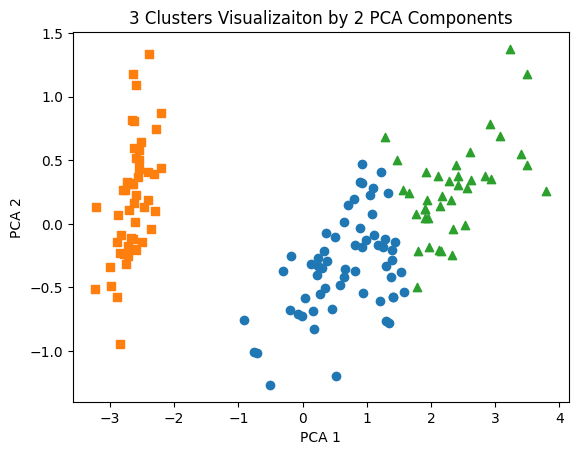

In [11]:
# 군집 값이 0, 1, 2인 경우마다 별도의 인덱스로 추출
marker0_ind = irisDF[irisDF['cluster']==0].index
marker1_ind = irisDF[irisDF['cluster']==1].index
marker2_ind = irisDF[irisDF['cluster']==2].index

# 군집 값 0, 1, 2에 해당하는 인덱스로 각 군집 레벨의 pca_x, pca_y 값 추출. o, s, ^로 마커 표시
plt.scatter(x=irisDF.loc[marker0_ind, 'pca_x'], y=irisDF.loc[marker0_ind, 'pca_y'], marker='o')
plt.scatter(x=irisDF.loc[marker1_ind, 'pca_x'], y=irisDF.loc[marker1_ind, 'pca_y'], marker='s')
plt.scatter(x=irisDF.loc[marker2_ind, 'pca_x'], y=irisDF.loc[marker2_ind, 'pca_y'], marker='^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualizaiton by 2 PCA Components')
plt.show()

- Cluster 1(네모)은 다른 군집들과 명확하게 분리되어 있음.
- Cluster 0(동그라미)과 Cluster 2(세모)는 어느 정도 구분되지만 완전히 분리되지는 않음.
- 특히 Cluster 0과 Cluster 1은 일부 영역에서 데이터 위치가 겹쳐 명확한 구분이 어려움.

###군집화 알고리즘 테스트를 위한 데이터 생성
- 사이킷런은 군집화 실험용 데이터 생성기로 make_blobs()와 make_classification()을 제공함.
- make_blobs()는 군집 중심점과 표준편차를 조절할 수 있고, make_classification()은 노이즈가 포함된 데이터 생성에 유용함.
- make_circle()과 make_moons()는 중심 기반 군집화로 구분하기 어려운 형태의 데이터 생성에 사용됨.

####make_blobs()의 호출 파라미터
- n_samples
  - 생성할 데이터의 개수
  - 디폴트 = 100개
- n_features
  - 데이터의 피처 개수
  - 시각화를 목표로 할 경우 2개로 설정해 보통 첫 번째 피처는 x좌표, 두 번째 피처는 y좌표상에 표현
- centers
  - 예: 3으로 설정하면 군집의 개수를 나타냄.
  - ndarray 형태로 표현할 경우 개별 군집 중심점의 좌표를 의미
- cluster_std
  - 생성될 군집 데이터의 표준 편차
  - float 값 0.8과 같은 형태로 지정 -> 군집 내에서 데이터가 표준편차 0.8을 가진 값으로 만들어짐.
  - [0.8, 1.2, 0.6]과 같은 형태 -> 3개의 군집에서 첫 번째 군집 내 데이터의 표준편차는 0.8, 두 번째 군집 내 데이터의 표준 편차는 1.2, 세 번째 군집 내에서 데이터의 표준편차는 0.6으로 만듦.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

X, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.8, random_state=0)
print(X.shape, y.shape)

# y target 값의 분포를 확인
unique, counts = np.unique(y, return_counts=True)
print(unique, counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


In [13]:
import pandas as pd
clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y
clusterDF.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


- 타깃값 0, 1, 2에 따라 마커를 다르게 해서 산점도를 그리기
- 3개의 구분될 수 있는 군집 영역(make_blobs( )이 y 반환 값)

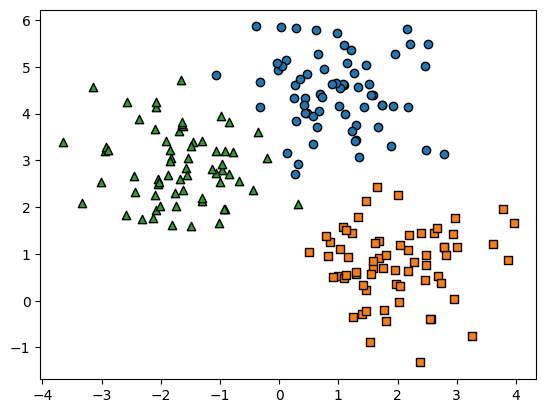

In [14]:
target_list = np.unique(y)
# 각 타깃별 산점도의 마커 값.
markers = ['o', 's', '^', 'P', 'D', 'H', 'x']
# 3개의 군집 영역으로 구분한 데이터 세트를 생성했으므로 target_list는 [0, 1, 2]
# target==0, target==1, target==2 로 scatter plot을 marker별로 생성.
for target in target_list:
  target_cluster = clusterDF[clusterDF['target']==target]
  plt.scatter(x=target_cluster['ftr1'], y=target_cluster['ftr2'], edgecolor='k',
              marker=markers[target])
plt.show()

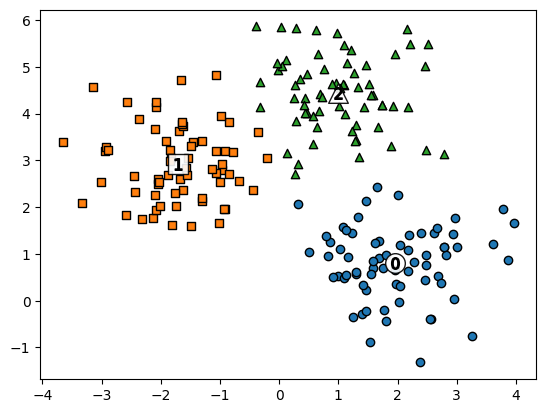

In [15]:
# KMeans 객체를 이용해 X 데이터를 K-Means 클러스터링 수행
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=200, random_state=0)
cluster_labels = kmeans.fit_predict(X)
clusterDF['kmeans_label'] = cluster_labels

# cluster_centers_는 개별 클러스터의 중심 위치 좌표 시각화를 위해 추출
centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

# 군집된 label 유형별로 iteration 하면서 marker 별로 scatter plot 수행.
for label in unique_labels:
  label_cluster = clusterDF[clusterDF['kmeans_label']==label]
  center_x_y = centers[label]
  plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
              marker=markers[label])

  # 군집별 중신 위치 좌표 시각화
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='white',
              alpha=0.9, edgecolor='k', marker=markers[label])
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k',
              marker='$%d$' % label)
plt.show()

In [16]:
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


- cluster_std가 작을수록 군집 중심에 데이터가 모여 있으며, 클수록 데이터가 퍼져 있음.

##7.2 군집 평가(Cluster Evaluation)
- 군집화 데이터는 대부분 정답 레이블이 없어 분류처럼 정확한 성능 평가가 어려움.
- 군집화는 숨겨진 그룹을 찾거나 데이터를 더 세분화하는 등 분류와 다른 목적을 가짐.
- 비지도학습의 특성상 평가가 쉽지 않지만, 대표적인 군집화 성능 평가 방법으로 실루엣 분석을 사용함.

###실루엣 분석의 개요
- 실루엣 분석은 군집 간 분리가 얼마나 잘 이루어졌는지를 평가하는 방법임.
- 군집화가 잘될수록 같은 군집의 데이터는 서로 가깝고, 다른 군집의 데이터와는 멀리 떨어져 있음.

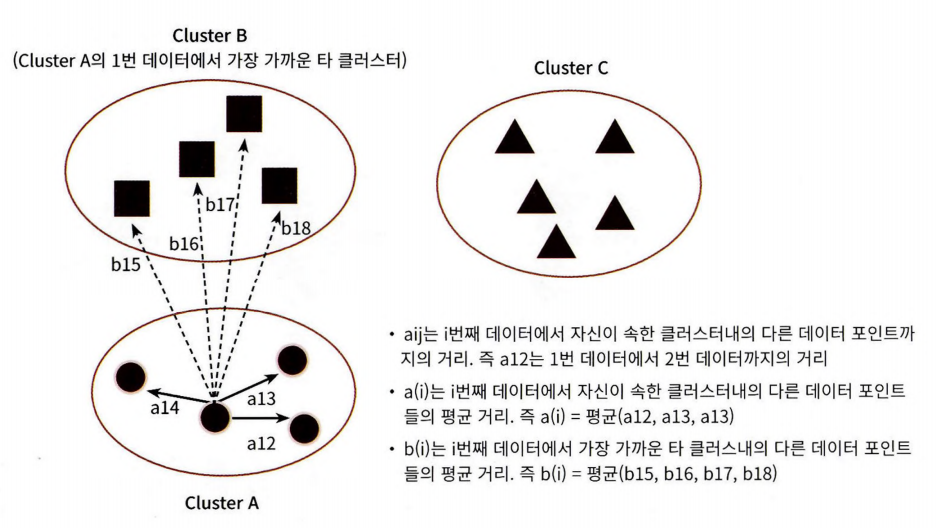

####실루엣 계수
- 각 데이터가 자신의 군집에 얼마나 잘 속해 있고 다른 군집과는 얼마나 구분되는지를 나타내는 지표
- a(i): 같은 군집 내 데이터와의 평균 거리
- b(i): 가장 가까운 다른 군집과의 평균 거리
- b(i)−a(i)가 클수록 해당 데이터는 자신의 군집에 잘 속하고 다른 군집과는 잘 분리되어 있음을 의미함.
- 실루엣 계수는 -1에서 1 사이의 값을 가짐.
  - 값이 1에 가까울수록 자신의 군집에 잘 속해 있으며 다른 군집과는 멀리 떨어져 있음을 의미함.
  - 값이 0에 가까우면 군집 간 경계에 위치하고, -1에 가까우면 잘못된 군집에 할당되었음을 의미함.

####실루엣 분석을 위한 메서드
- sklearn.metrics.silhouette_samples(X, labels, metric='euclidean', **kwds)
  - 인자로 X feature 데이터 세트와 각 피처 데이터 세트가 속한 군집 레이블 값인 labels 데이터를 입력해주면 각 데이터 포인트의 실루엣 계수를 계산해 반환
- sklearn.metrics.silhouette_score(X, labels, metric='euclidean', sample_size=None, **kwds)
  - 인자로 X feature 데이터 세트와 각 피처 데이터 세트가 속한 군집 레이블 값인 labels 데이터를 입력해주면 전체 데이터의 실루엣 계수 값을 평균해 반환.
  - np.mean(silhouette_samples()) 반환.
  - 일반적으로 이 값이 높을수록 군집화가 어느 정도 잘 됐다고 판단 가능.(But 무조건 X)

####좋은 군집화가 되기 위한 조건
1. 전체 실루엣 계수의 평균값, 즉 사이킷런의 silhouette_score() 값은 0~1 사이의 값을 가지며, 1에 가까울수록 좋음.
2. 전체 실루엣 계수 평균값이 높은 것뿐만 아니라 군집별 평균값도 고르게 나타나야 함.
  - 각 군집의 실루엣 계수 평균이 전체 평균에서 크게 벗어나지 않는 것이 중요함.
  - 특정 군집만 실루엣 계수가 높고 나머지 군집이 낮다면 바람직한 군집화 결과라고 보기 어려움.

###붓꽃 데이터 세트를 이용한 군집 평가

In [17]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
# 실루엣 분석 평가 지표 값을 구하기 위한 API 추가
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(irisDF)
irisDF['cluster'] = kmeans.labels_

# iris의 모든 개별 데이터에 실루엣 계수 값ㅇㄹ 구함.
score_samples = silhouette_samples(iris.data, irisDF['cluster'])
print('silhouette_samples() return 값의 shape', score_samples.shape)

# irisDF에 실루엣 계수 칼럼 추가
irisDF['silhouette_coeff'] = score_samples

# 모든 데이터의 평균 실루엣 계수 값을 구함.
average_score = silhouette_score(iris.data, irisDF['cluster'])
print('붓꽃 데이터 세트 Silhouette Analysis Score:{0:.3f}'.format(average_score))
irisDF.head(3)

silhouette_samples() return 값의 shape (150,)
붓꽃 데이터 세트 Silhouette Analysis Score:0.551


,sepal_length,sepal_width,petal_length,petal_width,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797


- 붓꽃 데이터 세트의 평균 실루엣 계수는 약 0.553으로 비교적 양호한 군집화 결과를 보임.
- 1번 군집은 개별 실루엣 계수가 약 0.8 이상으로 매우 높아 군집 내 응집도와 군집 간 분리도가 우수함.
- 반면 다른 군집들의 실루엣 계수가 상대적으로 낮아 전체 평균 실루엣 계수는 0.553 수준으로 나타남.

In [18]:
irisDF.groupby('cluster')['silhouette_coeff'].mean()

,silhouette_coeff
cluster,
0,0.422323
1,0.797604
2,0.436842


- 1번 군집은 실루엣 계수 평균 값이 약 0.79인데 반해, 0번은 약 0.41, 2번은 0.45로 상대적으로 평균값이 1번에 비해 낮음.


###군집별 평균 실루엣 계수의 시각화를 통한 군집 개수 최적화 방법
- 평균 실루엣 계수가 높다고 해서 반드시 최적의 군집 개수라고 볼 수는 없음.
- 특정 군집만 실루엣 계수가 높고 다른 군집의 계수가 낮아도 전체 평균은 높게 나타날 수 있음.
- 군집 간 적절한 분리와 군집 내 높은 응집도가 함께 나타날 때 적절한 군집 개수로 판단할 수 있음.

[소스코드 예시](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html)

####군집 개수 2개
- 군집 개수를 2개로 설정했을 때 평균 실루엣 계수는 약 0.704로 높게 나타남.
- 하지만 1번 군집은 대부분 평균 이상의 실루엣 계수를 가지는 반면, 2번 군집은 평균 이하인 데이터가 많음.
- 따라서 평균 실루엣 계수만으로 최적의 군집 개수를 판단할 수 없으며, 군집별 실루엣 분포도 함께 확인해야 함.
  - 1번 군집의 경우는 0번 군집과 멀리 떨어져 있고, 내부 데이터끼리도 잘 뭉쳐 있음.
  - 하지만 0번 군집의 경우는 내부 데이터끼리 많이 떨어짐.

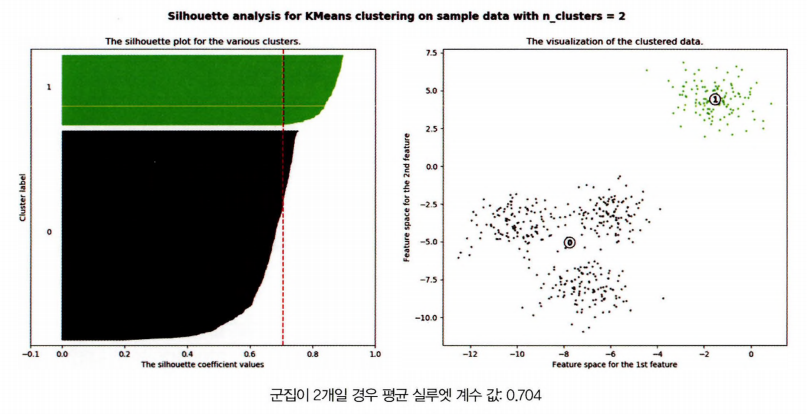

####군집 개수 3개
- 전체 데이터의 평균 실루엣 계수는 약 0.588로 나타남.
- 1번과 2번 군집은 평균보다 높은 실루엣 계수를 가지지만, 0번 군집은 대부분 평균보다 낮은 값을 가짐.
- 이는 0번 군집의 데이터들이 서로 멀리 떨어져 있고 2번 군집과도 가까워 군집 분리가 명확하지 않기 때문임.
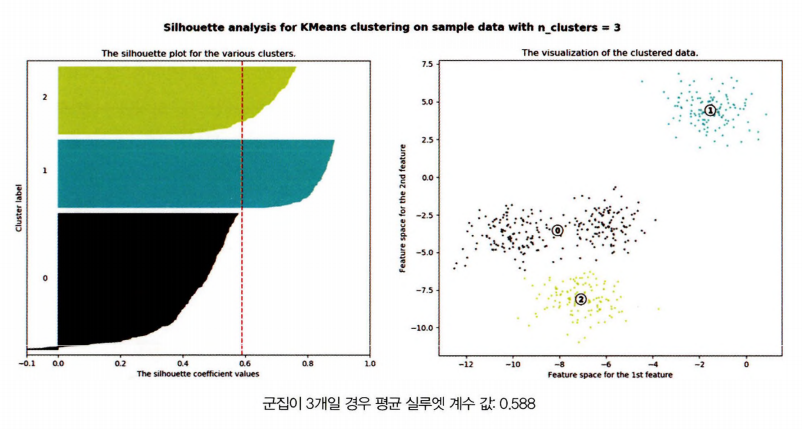

####군집 개수 4개
- 군집 개수를 4개로 설정했을 때 평균 실루엣 계수는 약 0.65로 나타남.
- 각 군집의 실루엣 계수가 비교적 고르게 분포하여 군집 간 균형이 잘 유지됨.
- 평균 실루엣 계수는 2개 군집일 때보다 낮지만, 군집별 분포가 더 안정적이어서 4개가 가장 적절한 군집 개수로 판단됨.

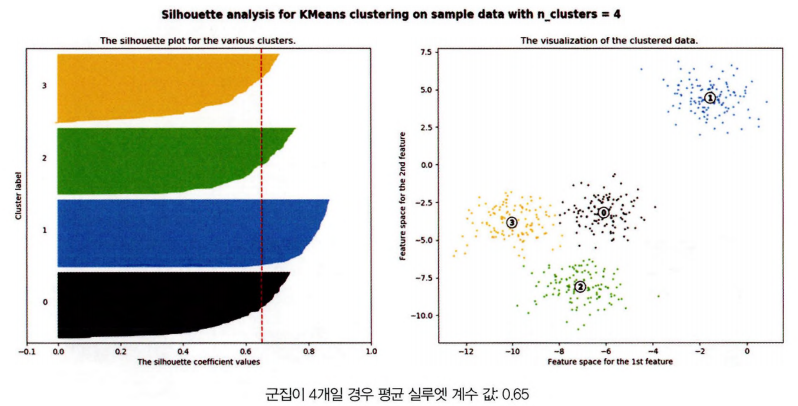

In [21]:
### 여러개의 클러스터링 갯수를 List로 입력 받아 각각의 실루엣 계수를 면적으로 시각화한 함수 작성
def visualize_silhouette(cluster_lists, X_features):

    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math

    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)

    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):

        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산.
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현.
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

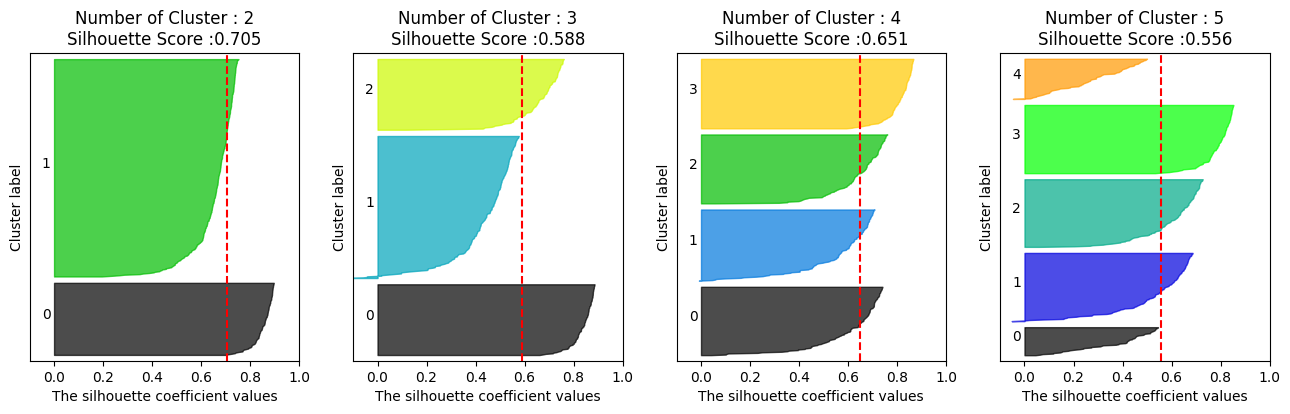

In [23]:
# make_blobs를 통해 군집화를 위한 4개의 군집 중심의 500개 2차원 데이터 세트 생성
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1,
                  center_box=(-10.0, 10.0), shuffle=True, random_state=1)

# 군집 개수가 2개, 3개, 4개, 5개일 때의 군지별 실루엣 계수 평균값을 시각화
visualize_silhouette([2,3,4,5], X)

- 4개의 군집일 때 가장 최적이 됨.

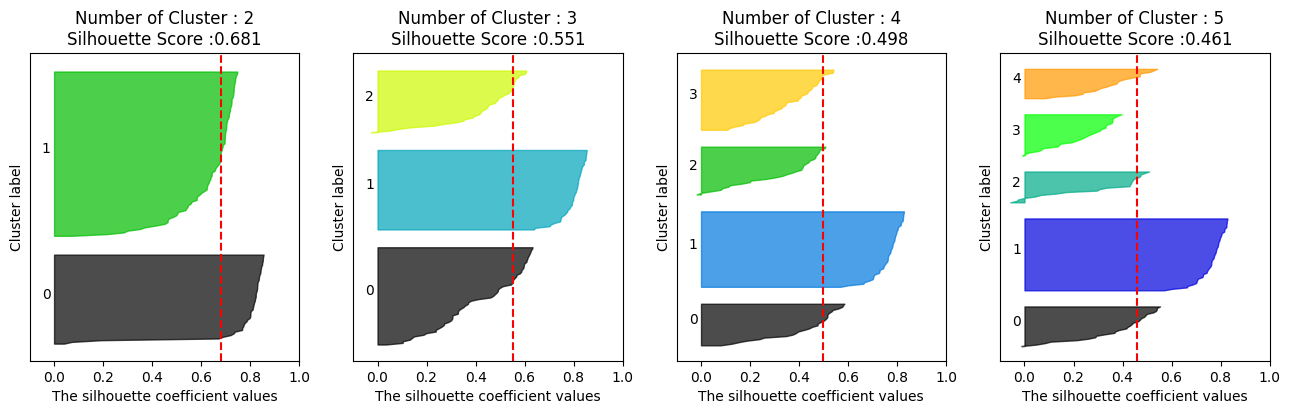

In [26]:
from sklearn.datasets import load_iris
iris=load_iris()
visualize_silhouette([2,3,4,5], iris.data)

- 붓꽃 데이터는 K-평균 군집화 시 군집 개수를 2개로 설정했을 때 가장 높은 실루엣 계수를 보여 상대적으로 적절한 결과를 나타냄.
- 군집 개수를 3개 이상으로 늘리면 평균 실루엣 계수가 감소하고 군집 간 실루엣 계수 편차도 커짐.
- 실루엣 계수 계산은 모든 데이터 간 거리를 반복적으로 계산하므로 데이터가 많을 경우 시간이 오래 걸리며, 대용량 데이터에서는 샘플링을 활용해 평가할 수 있음.